In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
df = pd.read_csv('Salaries.csv')

In [3]:
df = df[df.columns[1:]]

In [4]:
df

,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,Prof,B,19,18,Male,139750
1,Prof,B,20,16,Male,173200
2,AsstProf,B,4,3,Male,79750
3,Prof,B,45,39,Male,115000
4,Prof,B,40,41,Male,141500
...,...,...,...,...,...,...
392,Prof,A,33,30,Male,103106
393,Prof,A,31,19,Male,150564
394,Prof,A,42,25,Male,101738
395,Prof,A,25,15,Male,95329


## Analyzing Data Set

array([[<Axes: title={'center': 'salary'}>]], dtype=object)

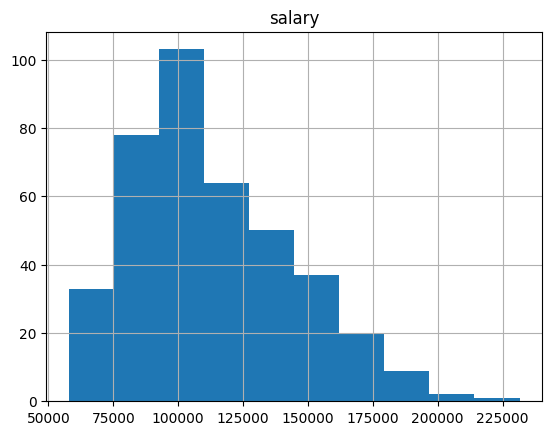

In [5]:
df[['salary']].hist()

<Axes: xlabel='rank'>

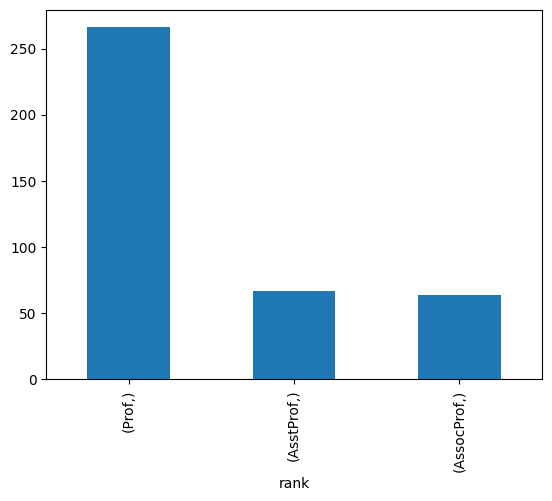

In [6]:
df[['rank']].value_counts().plot(kind='bar')

<Axes: xlabel='sex,rank'>

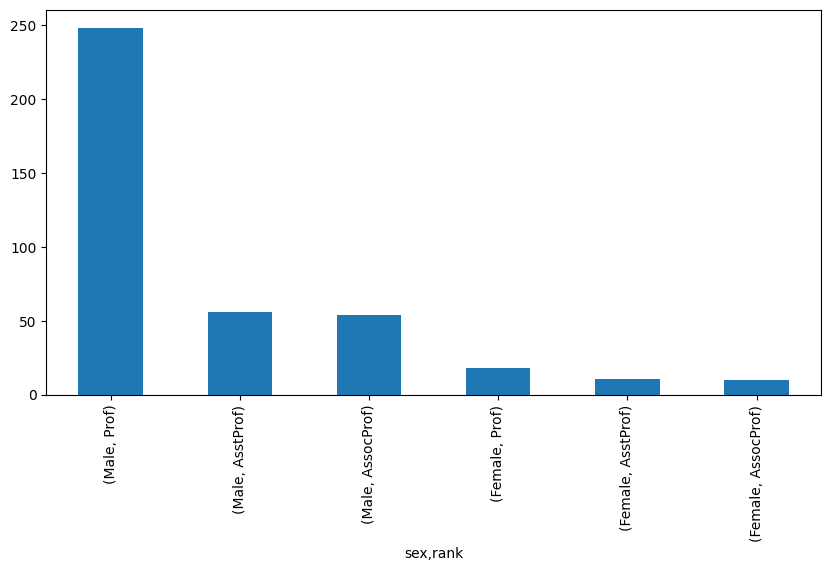

In [7]:
plt.figure(figsize=(10,5))
df[['sex', 'rank']].value_counts().plot(kind='bar')

## Real Working

In [8]:
df

,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,Prof,B,19,18,Male,139750
1,Prof,B,20,16,Male,173200
2,AsstProf,B,4,3,Male,79750
3,Prof,B,45,39,Male,115000
4,Prof,B,40,41,Male,141500
...,...,...,...,...,...,...
392,Prof,A,33,30,Male,103106
393,Prof,A,31,19,Male,150564
394,Prof,A,42,25,Male,101738
395,Prof,A,25,15,Male,95329


In [9]:
df = pd.get_dummies(df, drop_first=True)

In [10]:
df

,yrs.since.phd,yrs.service,salary,rank_AsstProf,rank_Prof,discipline_B,sex_Male
0,19,18,139750,False,True,True,True
1,20,16,173200,False,True,True,True
2,4,3,79750,True,False,True,True
3,45,39,115000,False,True,True,True
4,40,41,141500,False,True,True,True
...,...,...,...,...,...,...,...
392,33,30,103106,False,True,False,True
393,31,19,150564,False,True,False,True
394,42,25,101738,False,True,False,True
395,25,15,95329,False,True,False,True


In [11]:
y = df[['salary']]
X = df.drop(columns=['salary'])

In [13]:
X

,yrs.since.phd,yrs.service,rank_AsstProf,rank_Prof,discipline_B,sex_Male
0,19,18,False,True,True,True
1,20,16,False,True,True,True
2,4,3,True,False,True,True
3,45,39,False,True,True,True
4,40,41,False,True,True,True
...,...,...,...,...,...,...
392,33,30,False,True,False,True
393,31,19,False,True,False,True
394,42,25,False,True,False,True
395,25,15,False,True,False,True


In [14]:
import statistics
average_r2 = []

for each_main in range(10):
    for each in range(10):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)
        reg = LinearRegression().fit(X_train, y_train)
        y_pred_test = reg.predict(X_test)
        average_r2.append(r2_score(y_test, y_pred_test))

    print(round(statistics.mean(average_r2)*100, 0))

42.0
42.0
42.0
42.0
42.0
42.0
43.0
43.0
43.0
42.0


In [16]:
X = X.astype(int)
X = sm.add_constant(X)
mod = sm.OLS(y, X)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     54.20
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.79e-48
Time:                        16:31:26   Log-Likelihood:                -4538.9
No. Observations:                 397   AIC:                             9092.
Df Residuals:                     390   BIC:                             9120.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7.886e+04   4990.326     15.803

## Removing gender dummy variable

In [17]:
X = df.drop(columns=['sex_Male'])

In [18]:
X

,yrs.since.phd,yrs.service,salary,rank_AsstProf,rank_Prof,discipline_B
0,19,18,139750,False,True,True
1,20,16,173200,False,True,True
2,4,3,79750,True,False,True
3,45,39,115000,False,True,True
4,40,41,141500,False,True,True
...,...,...,...,...,...,...
392,33,30,103106,False,True,False
393,31,19,150564,False,True,False
394,42,25,101738,False,True,False
395,25,15,95329,False,True,False


In [19]:
import statistics
average_r2 = []

for each_main in range(10):
    for each in range(10):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)
        reg = LinearRegression().fit(X_train, y_train)
        y_pred_test = reg.predict(X_test)
        average_r2.append(r2_score(y_test, y_pred_test))

    print(statistics.mean(average_r2))

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
